# Ejercicio K Nearest Neighbors (KNN)- Solución

Este es un ejercicio simple, parecido al que realizamos en clase...solo que con otro conjunto de datos.  Solamente deben seguir las instrucciones abajo indicadas.
## Importar las Librerias
**Import pandas,seaborn, y las otras acostumbradas.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtener los datos
**Lea el archivo 'Datos_Proyecto_KNN.csv' para que quede en un dataframe**

In [4]:
data = pd.read_csv("./Datos_Proyecto_KNN.csv")

**Verificar el encabezado del dataframe.**

In [5]:
data.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


# EDA

Como estos datos son ficticios genere una gráfica de tipo 'pairplot'.

**Utilice seaborn para crear un 'pairplot' con los colores indicados por la columna TARGET CLASS.**

d:\UVG GitHub Repositorios\2025\Mineria de Datos\.data_mining_venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
d:\UVG GitHub Repositorios\2025\Mineria de Datos\.data_mining_venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
d:\UVG GitHub Repositorios\2025\Mineria de Datos\.data_mining_venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
d:\UVG GitHub Repositorios\2025\Mineria de Datos\.data_mining_venv\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
d:\UVG GitHub Repositorios\2025\Mineria de Datos\.data_mining_venv\Lib\s

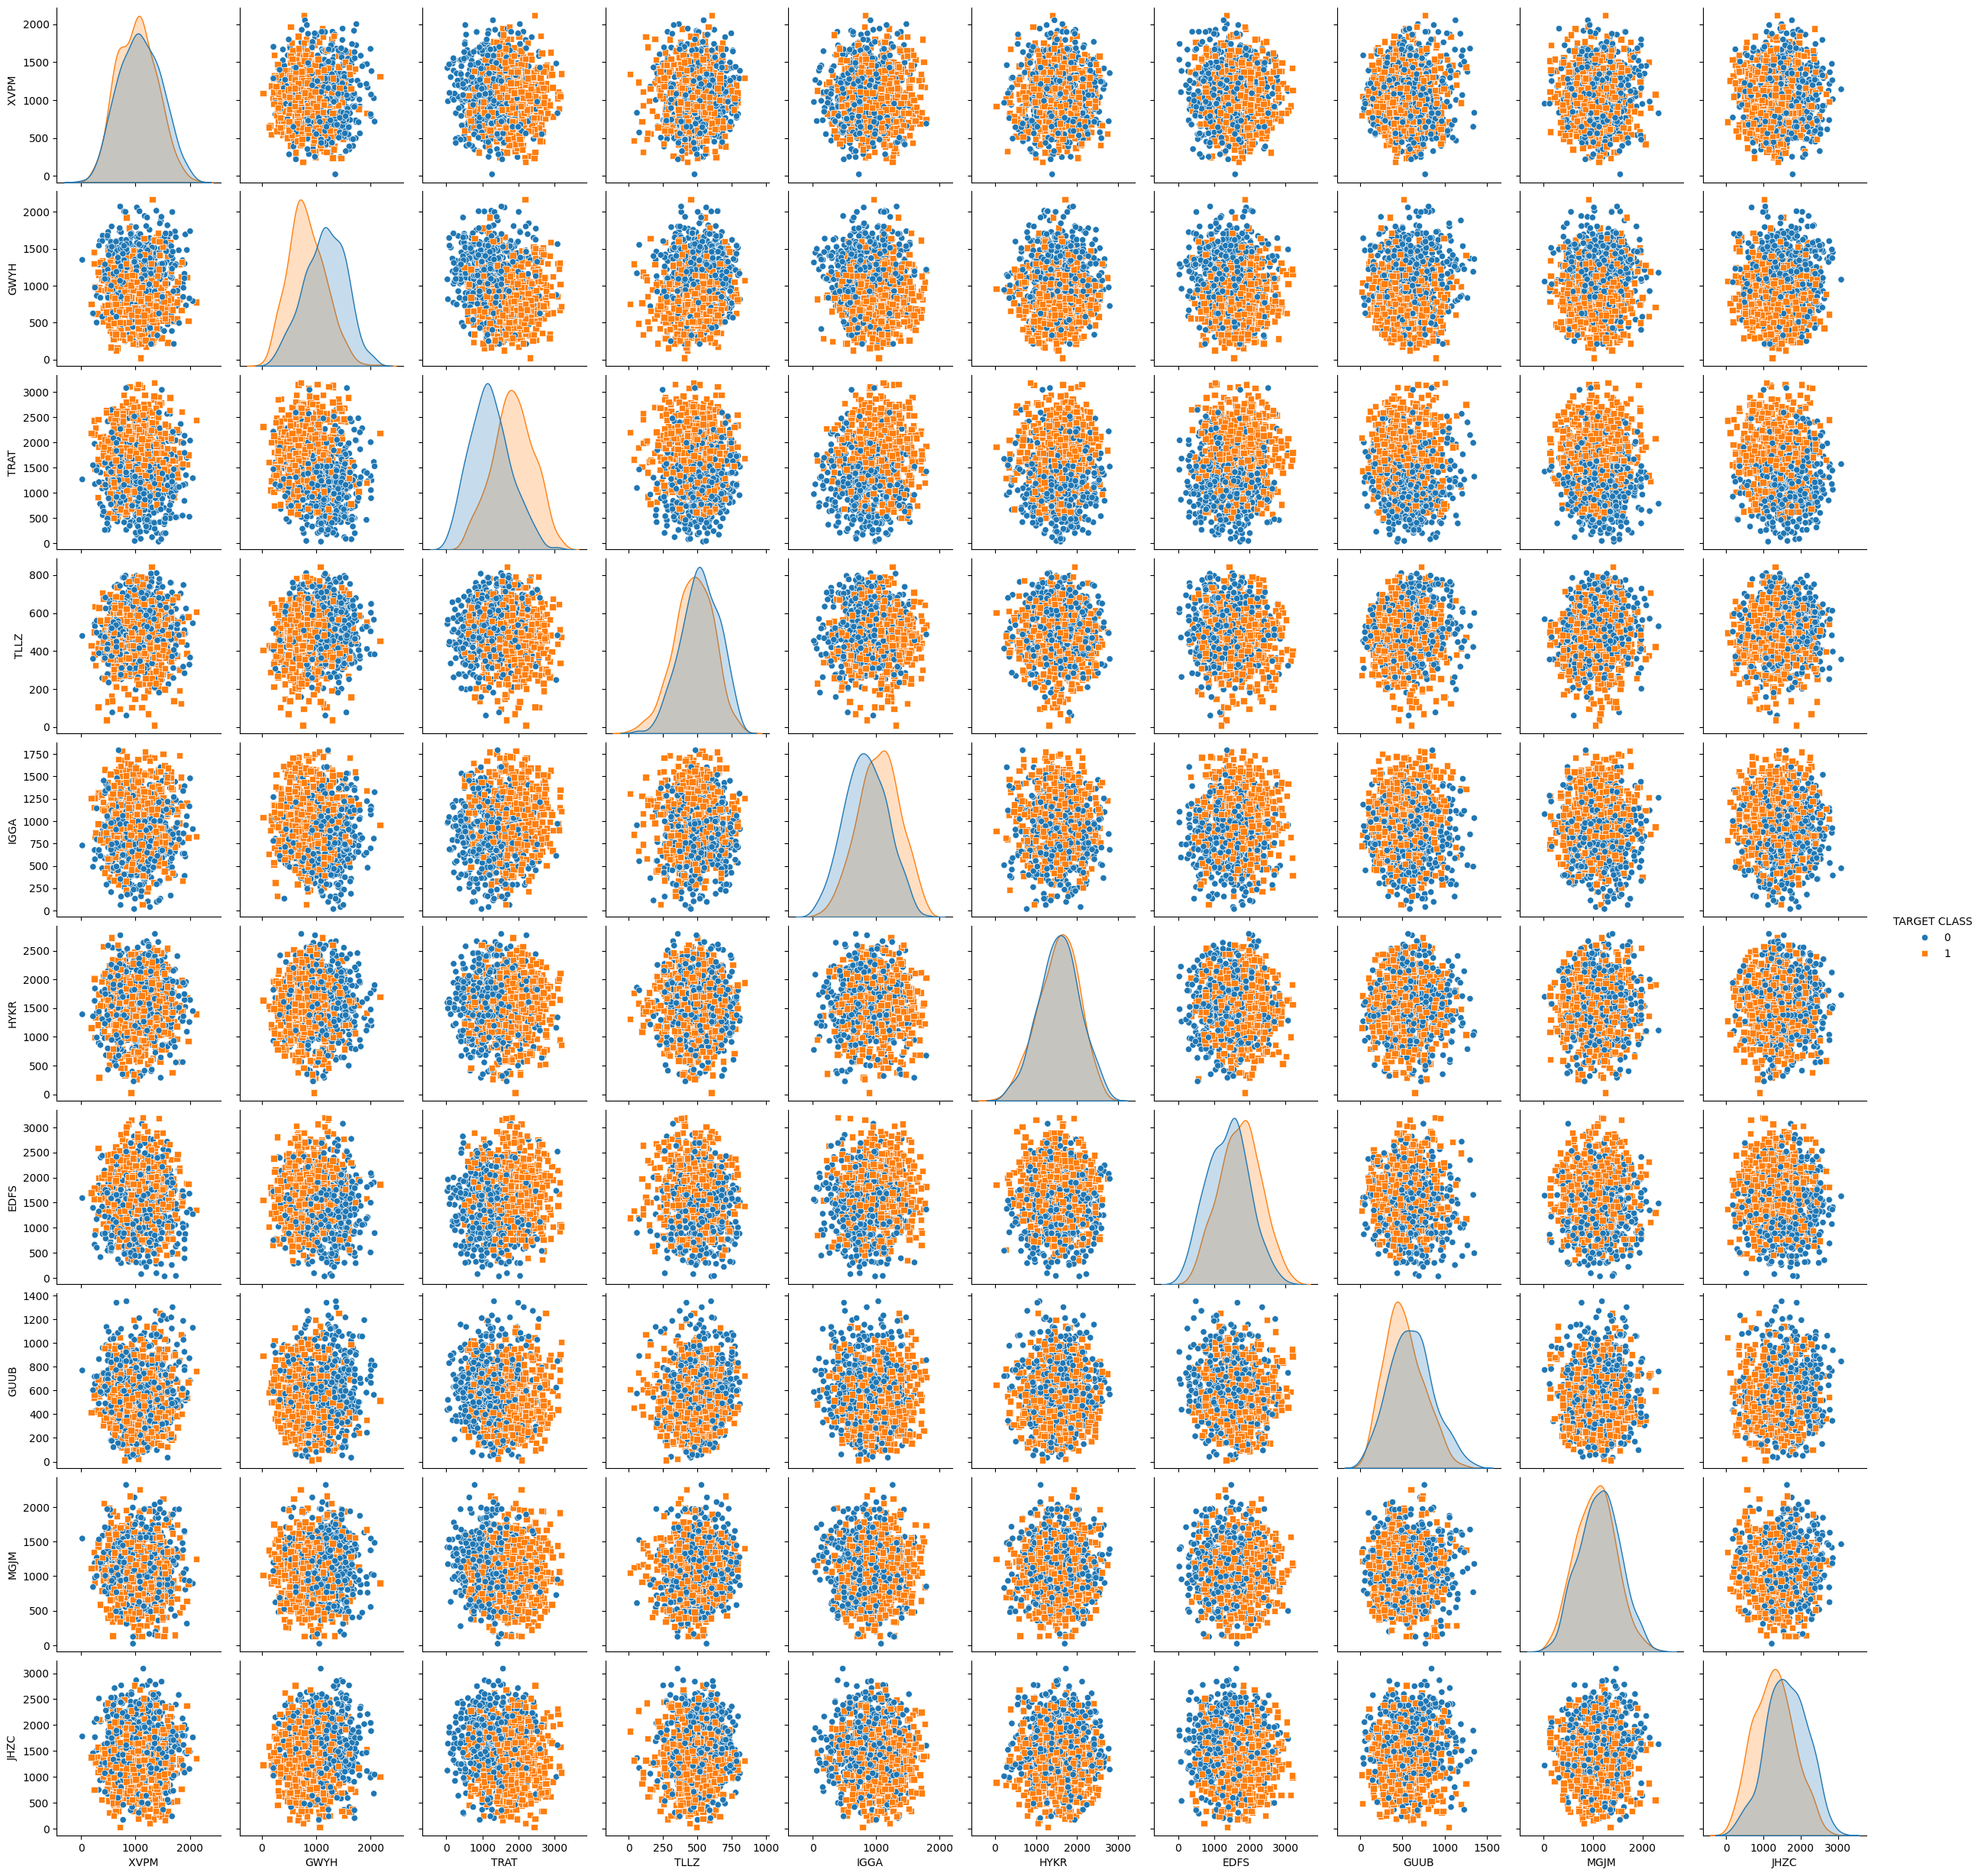

In [ ]:
# ESTA VA A SER UNA GRAFICA MUY GRANDE
sns.pairplot(data, hue="TARGET CLASS", markers=["o", "s"])


# Estandarizar o normalizar las Variables

Es momento de estandarizar las variables.

**Importe StandardScaler de Scikit learn.**

In [8]:
from sklearn.preprocessing import StandardScaler

**Instancie un objeto de StandardScaler() que se llame escalador.**

In [9]:
escalador = StandardScaler()

**Aplique el escalador a las variables (features).**

In [11]:
escalador.fit(data.drop('TARGET CLASS', axis = 1))

StandardScaler()

**Utilice el método .transform() para transformar las variables (features) a una versión normalizada.**

In [12]:
cols_std = escalador.transform(data.drop('TARGET CLASS', axis = 1))

**Convierta las variables normalizadas a un dataframe y verifique el encabezado de este dataframe para asegurar qur funcionó la normalización.**

In [14]:
datos_std = pd.DataFrame(cols_std, columns = data.columns[:-1])
datos_std.head()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC
0,1.568522,-0.443435,1.619808,-0.958255,-1.128481,0.138336,0.980493,-0.932794,1.008313,-1.069627
1,-0.112376,-1.056574,1.741918,-1.504220,0.640009,1.081552,-1.182663,-0.461864,0.258321,-1.041546
2,0.660647,-0.436981,0.775793,0.213394,-0.053171,2.030872,-1.240707,1.149298,2.184784,0.342811
3,0.011533,0.191324,-1.433473,-0.100053,-1.507223,-1.753632,-1.183561,-0.888557,0.162310,-0.002793
4,-0.099059,0.820815,-0.904346,1.609015,-0.282065,-0.365099,-1.095644,0.391419,-1.365603,0.787762


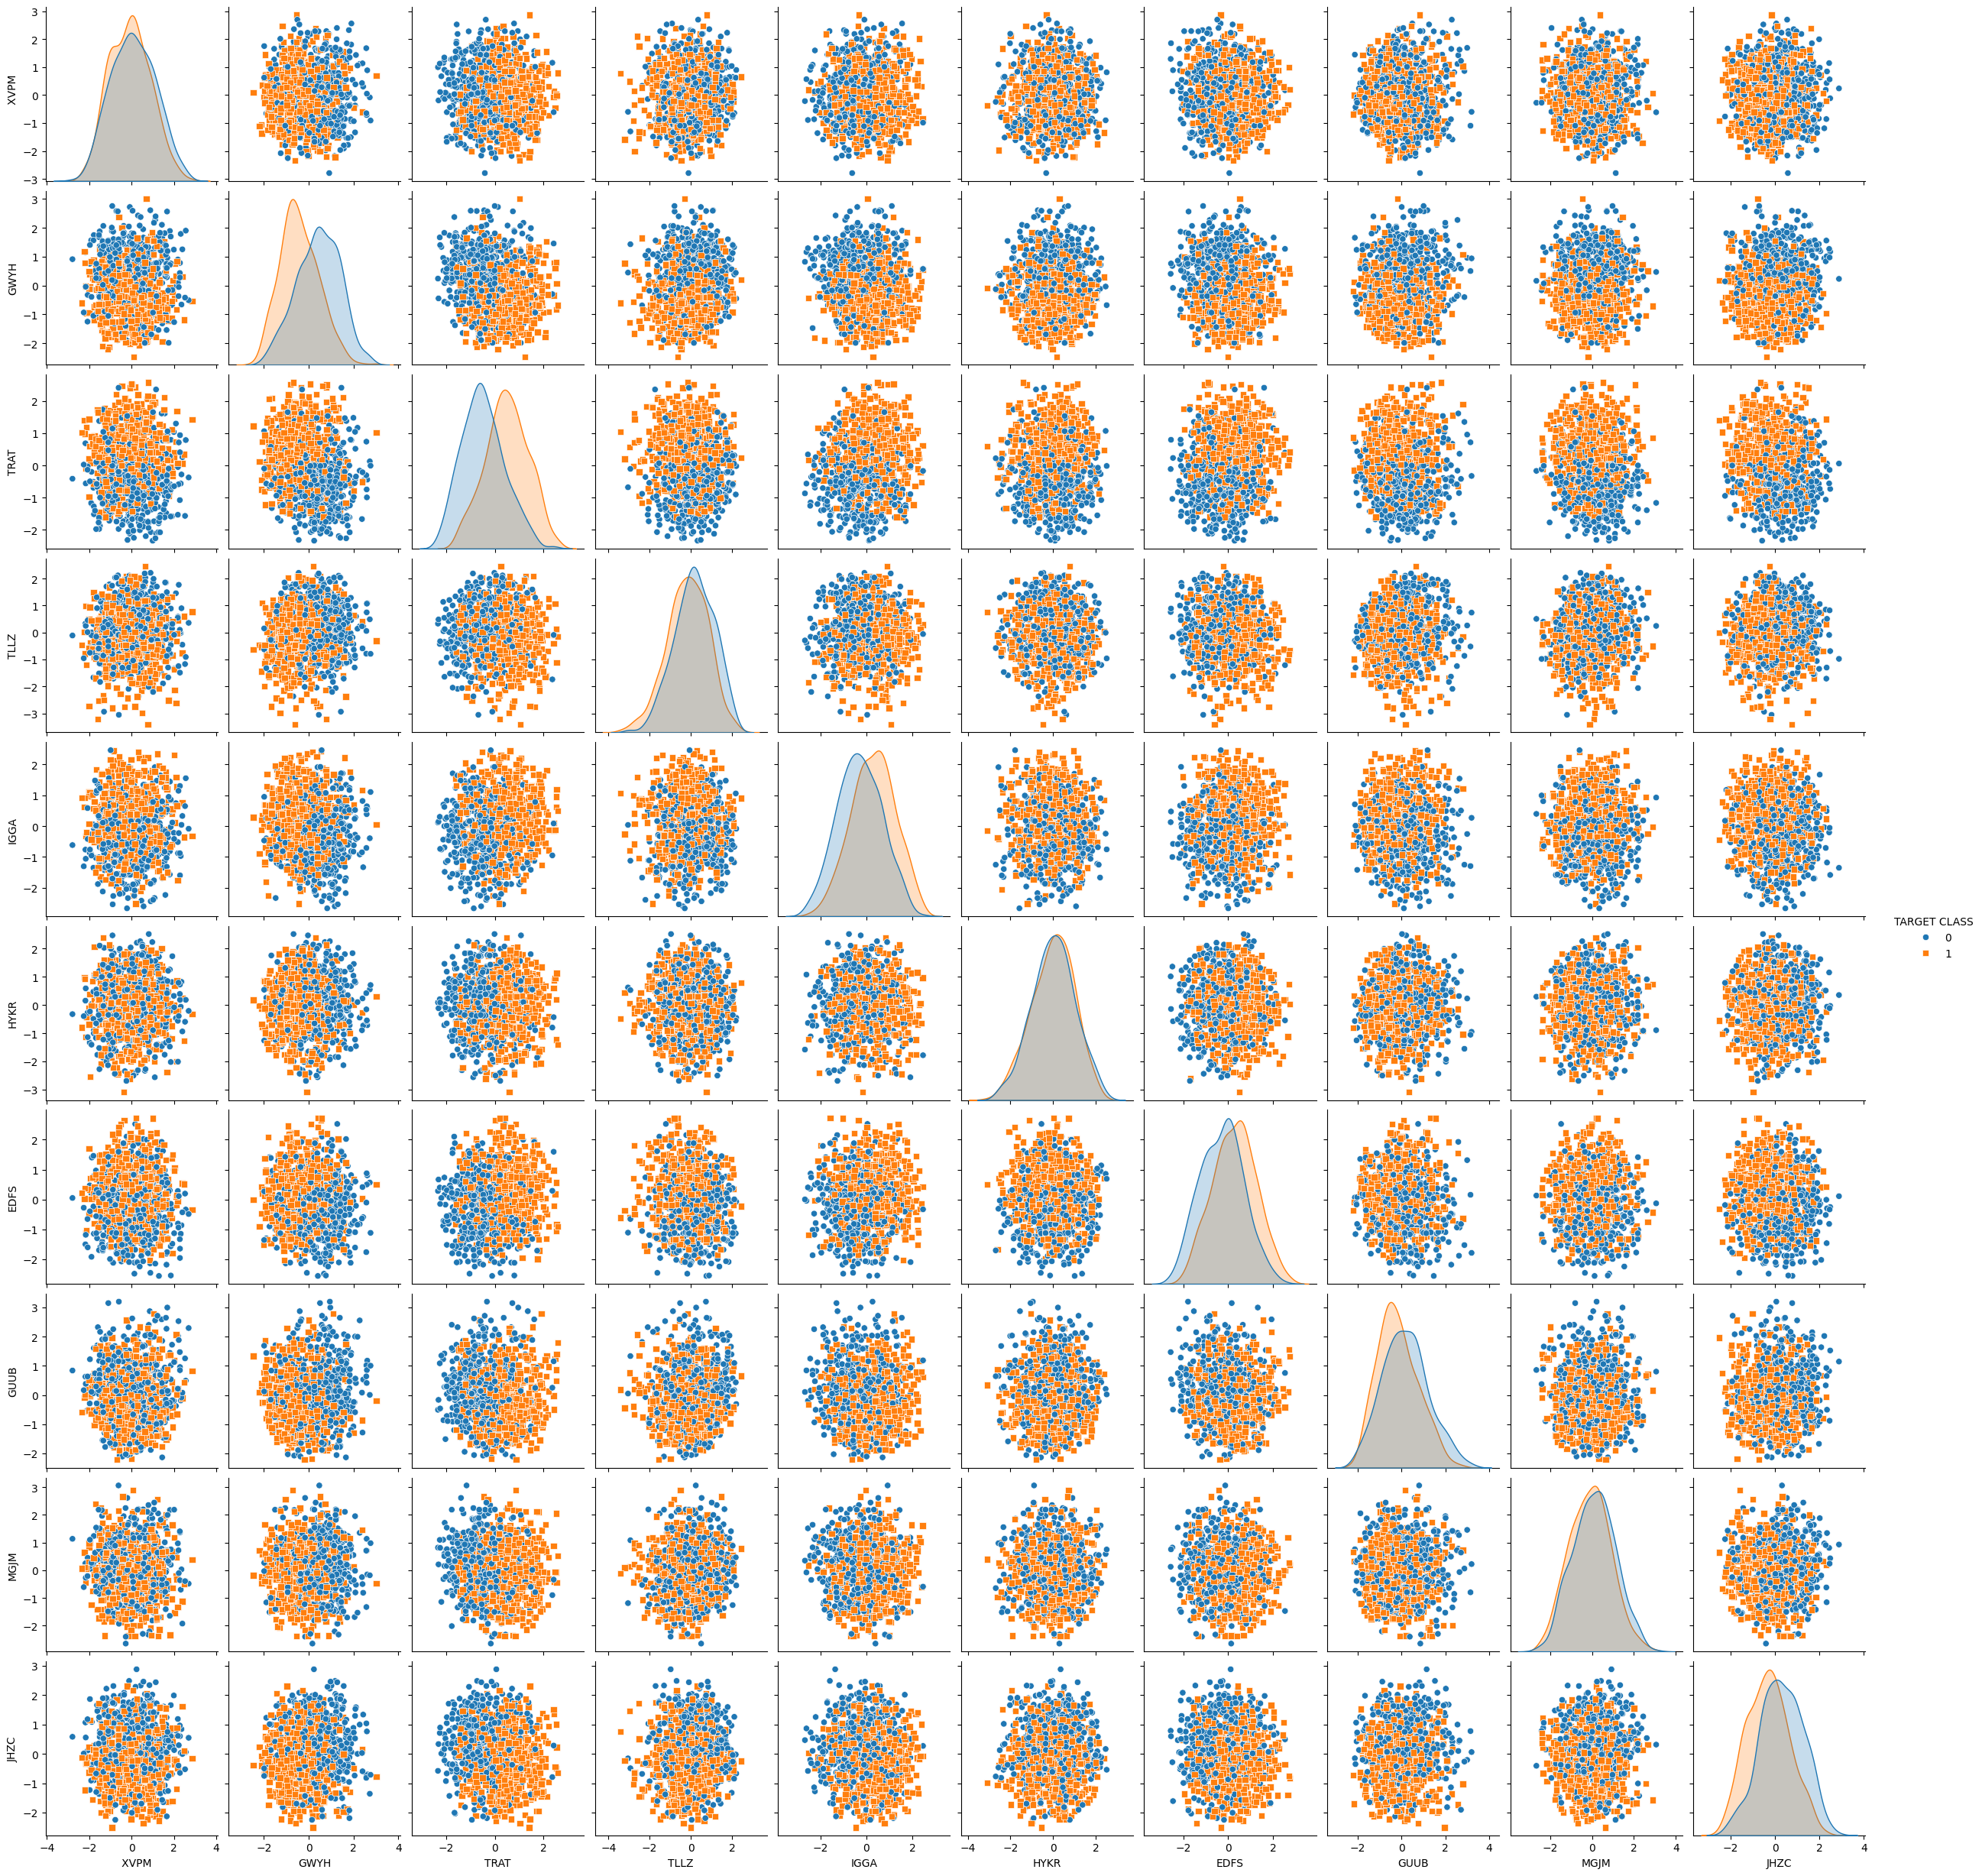

In [60]:
target_class = data["TARGET CLASS"]
new_data_std = pd.concat([datos_std, target_class], axis=1)
sns.pairplot(new_data_std, hue="TARGET CLASS", markers=["o", "s"])

# División Entrenamiento - Prueba (Train - Test Split)

**Utilice train_test_split para separar sus datos en un conjunto de entrenamiento y otro de prueba.**

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_entreno, X_prueba, y_entreno, y_prueba = train_test_split(cols_std, data['TARGET CLASS'],
                                                    test_size = 0.30, random_state = 0)

# Uso del KNN

**Importe KNeighborsClassifier de scikit learn.**

In [17]:
from sklearn.neighbors import KNeighborsClassifier

**Cree una instancia del modelo KNN con n_neighbors = 1**

In [18]:
knn = KNeighborsClassifier(n_neighbors = 1)

**Ajuste este modelo de KNN con los datos de entrenamiento.**

In [19]:
knn.fit(X_entreno, y_entreno)

KNeighborsClassifier(n_neighbors=1)

# Predicciones y Evaluaciones
Evalúe su modelo KNN!

**Utilice el método predict para predecir valores utilizando su modelo KNN y el conjunto de datos de prueba X_test.**

In [20]:
pred = knn.predict(X_prueba)

**Cree una matriz de confusión así como un reporte de clasificación.**

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

[[114  45]
 [ 31 110]]


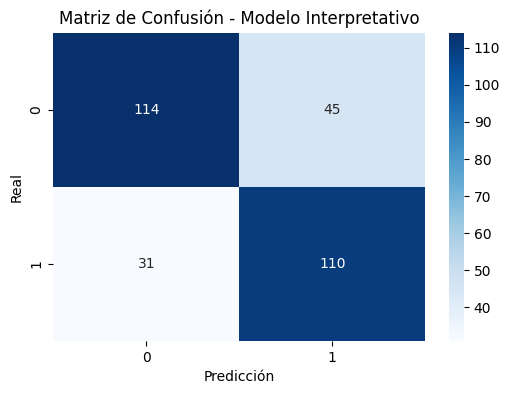

In [26]:
print(confusion_matrix(y_prueba, pred))
#  Matriz de confusión
conf_matrix = confusion_matrix(y_prueba, pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Interpretativo")
plt.show()



In [ ]:
print(classification_report(y_prueba, pred))

              precision    recall  f1-score   support

           0       0.79      0.72      0.75       159
           1       0.71      0.78      0.74       141

    accuracy                           0.75       300
   macro avg       0.75      0.75      0.75       300
weighted avg       0.75      0.75      0.75       300



# Selección de un valor para K
**Utilice el método de codo para seleccionar un buen valor de K!**

**Cree una iteración que entrene varios modelos KNN con diferentes valores de k.   Lleve control de la tasa de error para cada uno de estos modelos con una lista.  Vea el ejemplo realizado en clase si existe alguna confusión en este paso.**

In [27]:
tasa_error = []

# Puede tardar un poco
for i in range(1, 40):
    
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_entreno, y_entreno)
    pred_i = knn.predict(X_prueba)
    tasa_error.append(np.mean(pred_i != y_prueba))

**Ahora cree una gráfica de tasa-de-error vrs. k utilizando la información obtenida con la iteración.**

Text(0, 0.5, 'Tasa de Error')

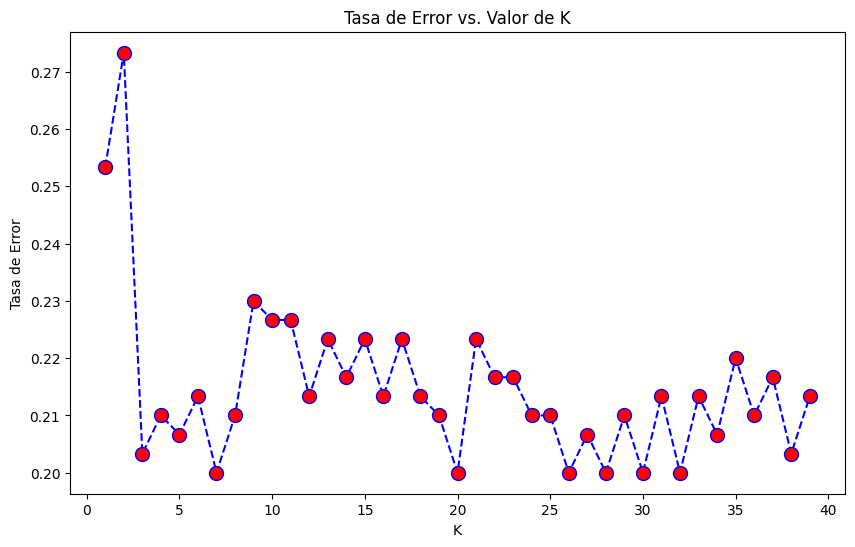

In [28]:
plt.figure(figsize = (10, 6))
plt.plot(range(1, 40), tasa_error, color = 'blue', linestyle = 'dashed', marker = 'o',
         markerfacecolor = 'red', markersize = 10)
plt.title('Tasa de Error vs. Valor de K')
plt.xlabel('K')
plt.ylabel('Tasa de Error')

In [ ]:
exactitud = []

# Puede tardar un poco
for i in range(1, 40):
    
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_entreno, y_entreno)
    pred_i = knn.predict(X_prueba)
    print(pred_i)
    print(y_prueba)
    exactitud.append(accuracy_score(y_pred=pred_i, y_true=y_prueba))
print(exactitud)

[1 1 0 1 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 0 1 1 1 0 1
 0 0 0 0 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 0 1 0 1 1 1 1 0 0 0 1 0 1 1 1
 1 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 1
 0 1 0 1 1 1 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 1 0 0 1 1
 0 1 0 0 1 1 0 0 1 0 1 0 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 1 0 0 1 0 1 1 0 1 0
 1 0 0 1 0 0 0 1 1 0 1 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 0 1 0 1 1 1 0 0
 1 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 0 0 1 0 0 1 0 1 0
 0 0 1 0 1 1 0 1 0 0 0 0 1 1 0 1 1 0 1 0 1 0 0 1 1 1 0 1 1 1 1 0 0 0 1 0 0
 1 1 0 0]
993    1
859    1
298    1
553    1
672    1
      ..
167    1
998    1
984    1
491    0
10     0
Name: TARGET CLASS, Length: 300, dtype: int64
[1 1 0 1 1 0 0 0 0 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 1 0 0 0 1
 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0
 1 1 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 1 1 0 1 0 0

Text(0, 0.5, 'Exactitud')

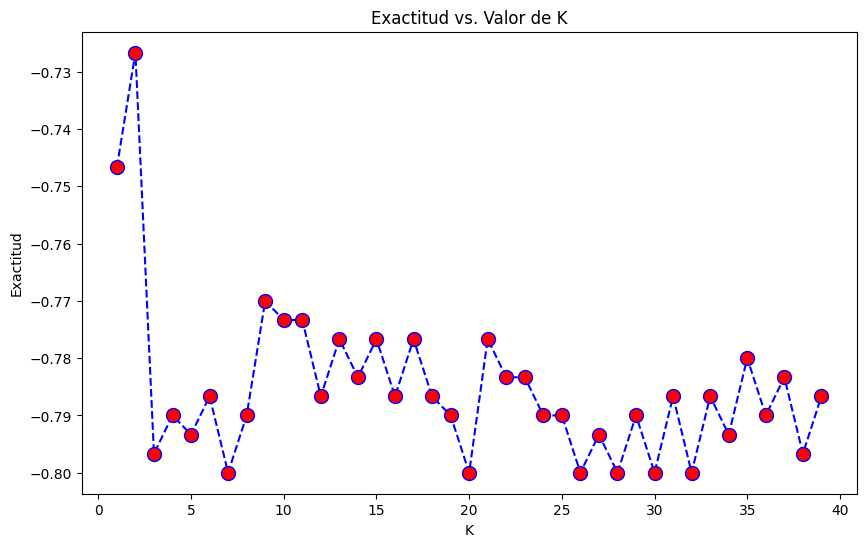

In [41]:
plt.figure(figsize = (10, 6))
plt.plot(range(1, 40), exactitud, color = 'blue', linestyle = 'dashed', marker = 'o',
         markerfacecolor = 'red', markersize = 10)
plt.title('Exactitud vs. Valor de K')
plt.xlabel('K')
plt.ylabel('Exactitud')

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from kneed import KneeLocator

# Lista para almacenar las puntuaciones de validación cruzada
scores = []

# Probar diferentes valores de n_neighbors
for k in range(1, 40):  # Ajusta el rango según lo que necesites
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_entreno, y_entreno, cv=5, scoring="accuracy")
    scores.append(cv_score.mean())

# Encontrar el codo en la curva de puntuaciones
k_values = range(1, 40)
localizador_codo = KneeLocator(k_values, scores, curve="convex", direction="decreasing")

print(f"El número óptimo de vecinos es: {localizador_codo.elbow}")
    
print(scores)


El número óptimo de vecinos es: 2
[np.float64(0.74), np.float64(0.7314285714285715), np.float64(0.7928571428571429), np.float64(0.7928571428571429), np.float64(0.8099999999999999), np.float64(0.8099999999999999), np.float64(0.8099999999999999), np.float64(0.8099999999999999), np.float64(0.8085714285714285), np.float64(0.8157142857142856), np.float64(0.8214285714285714), np.float64(0.8228571428571427), np.float64(0.8214285714285714), np.float64(0.8271428571428571), np.float64(0.8242857142857142), np.float64(0.8285714285714285), np.float64(0.8185714285714285), np.float64(0.8314285714285713), np.float64(0.8299999999999998), np.float64(0.8342857142857142), np.float64(0.8314285714285713), np.float64(0.8385714285714284), np.float64(0.8342857142857142), np.float64(0.8414285714285713), np.float64(0.8299999999999998), np.float64(0.8342857142857142), np.float64(0.8300000000000001), np.float64(0.8271428571428571), np.float64(0.8314285714285713), np.float64(0.8242857142857144), np.float64(0.828571

In [ ]:
import plotly.express as px
fig = px.line(datos_WCSS, x = "K" , y = "WCSS", title='WCSS vrs K')
fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of [0] but received: K

## Re-entrenar el modelo con el nuevo valor de K

**Vuelva a entrenar su modelo con el mejor valor de K (le queda a Ud decidir cuál quiere) y genere de nuevo la matriz de confusión y el reporte de clasificación.**

# Excelente trabajo!